In [4]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
 
from afd_vmodel  import afd_vmodel
from afd_explode import afd_explode
from wavemin    import wavemin
from surround   import surround
from near import near
from thrustmodel import thrustmodel

In [5]:
dt=.004
dtstep=.001
tmax=2.0
dx=5

In [6]:
vel,x,z=thrustmodel(dx)

In [7]:
vel.shape

(501, 1021)

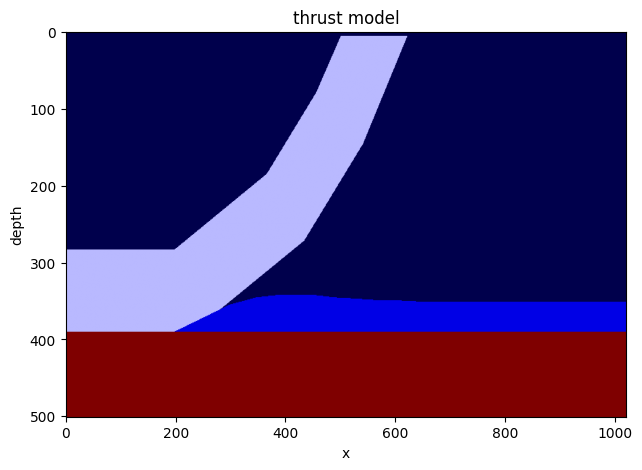

In [8]:
plt.figure(figsize=[8,5])
plt.imshow(vel, cmap='seismic', aspect=1.4)
plt.xlabel('x')
plt.ylabel('depth')
plt.title('thrust model')
plt.show()

In [9]:
xrec=x
zrec=x*0

In [11]:
seisf,seis,t=afd_explode(dx,dtstep,dt,tmax,vel,xrec,zrec,[5, 10, 40, 50],0,2)

There are 2000 steps to complete.
  wavefield propagated to 0.0810 s; time left ≈ 17.1 s
  wavefield propagated to 0.1620 s; time left ≈ 15.7 s
  wavefield propagated to 0.2430 s; time left ≈ 15.0 s
  wavefield propagated to 0.3240 s; time left ≈ 14.2 s
  wavefield propagated to 0.4050 s; time left ≈ 13.2 s
  wavefield propagated to 0.4860 s; time left ≈ 12.4 s
  wavefield propagated to 0.5670 s; time left ≈ 11.7 s
  wavefield propagated to 0.6480 s; time left ≈ 11.0 s
  wavefield propagated to 0.7290 s; time left ≈ 10.3 s
  wavefield propagated to 0.8100 s; time left ≈ 9.6 s
  wavefield propagated to 0.8910 s; time left ≈ 8.9 s
  wavefield propagated to 0.9720 s; time left ≈ 8.3 s
  wavefield propagated to 1.0530 s; time left ≈ 7.6 s
  wavefield propagated to 1.1340 s; time left ≈ 6.9 s
  wavefield propagated to 1.2150 s; time left ≈ 6.3 s
  wavefield propagated to 1.2960 s; time left ≈ 5.6 s
  wavefield propagated to 1.3770 s; time left ≈ 5.0 s
  wavefield propagated to 1.4580 s; tim

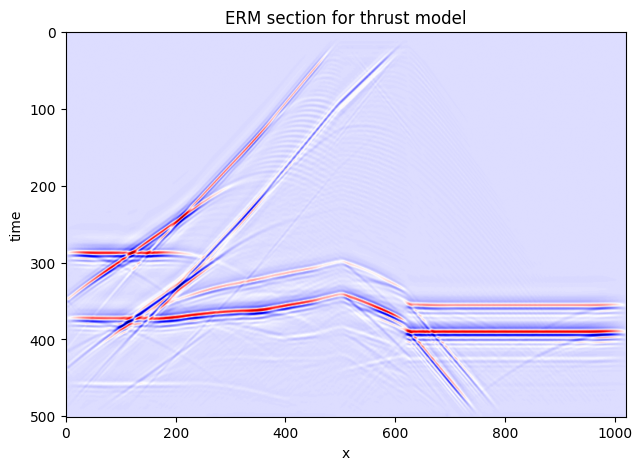

In [12]:
plt.figure(figsize=[8,5])
plt.imshow(seisf, cmap='seismic', aspect=1.4)
plt.xlabel('x')
plt.ylabel('time')
plt.title('ERM section for thrust model')
plt.show()

In [13]:
t[1]-t[0]

np.float64(0.004)

In [14]:
max(t)

np.float64(2.0)

In [16]:
vel.shape

(501, 1021)

In [17]:
#vrms,tv,vint=vz2vrms(vel,z,t[1]-t[0],max(t));

In [20]:
samprates=[dx,dx,dt]

In [22]:
from vz2vt import vz2vt

In [23]:
v,vrms,t,xs,ts = vz2vt(vel, seisf,samprates)

Calculating Two-way vertical travel times
Two-way vertical travel times calculated in 0.03 s
Resampling the velocity matrix from depth to time
Column 50 of 1021 resampled to time in 0.01 s
Column 100 of 1021 resampled to time in 0.01 s
Column 150 of 1021 resampled to time in 0.02 s
Column 200 of 1021 resampled to time in 0.03 s
Column 250 of 1021 resampled to time in 0.04 s
Column 300 of 1021 resampled to time in 0.05 s
Column 350 of 1021 resampled to time in 0.05 s
Column 400 of 1021 resampled to time in 0.06 s
Column 450 of 1021 resampled to time in 0.06 s
Column 500 of 1021 resampled to time in 0.07 s
Column 550 of 1021 resampled to time in 0.07 s
Column 600 of 1021 resampled to time in 0.08 s
Column 650 of 1021 resampled to time in 0.08 s
Column 700 of 1021 resampled to time in 0.09 s
Column 750 of 1021 resampled to time in 0.09 s
Column 800 of 1021 resampled to time in 0.10 s
Column 850 of 1021 resampled to time in 0.11 s
Column 900 of 1021 resampled to time in 0.11 s
Column 950 o

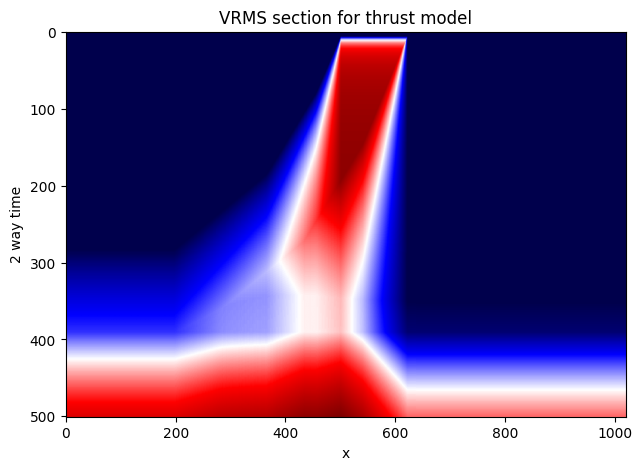

In [24]:
plt.figure(figsize=[8,5])
plt.imshow(vrms, cmap='seismic', aspect=1.4)
plt.xlabel('x')
plt.ylabel('2 way time')
plt.title('VRMS section for thrust model')
plt.show()

In [27]:
from kirk_mig import kirk_mig

In [29]:
seismig=kirk_mig(seisf,vrms,ts,xs)


 --- Total number of traces to be migrated : 1021 ---

 Migrated trace 20 of 1021, aperture traces: 581
 Estimated time remaining: 19 seconds
 Migrated trace 40 of 1021, aperture traces: 601
 Estimated time remaining: 19 seconds
 Migrated trace 60 of 1021, aperture traces: 621
 Estimated time remaining: 18 seconds
 Migrated trace 80 of 1021, aperture traces: 641
 Estimated time remaining: 18 seconds
 Migrated trace 100 of 1021, aperture traces: 661
 Estimated time remaining: 18 seconds
 Migrated trace 120 of 1021, aperture traces: 681
 Estimated time remaining: 18 seconds
 Migrated trace 140 of 1021, aperture traces: 701
 Estimated time remaining: 18 seconds
 Migrated trace 160 of 1021, aperture traces: 721
 Estimated time remaining: 18 seconds
 Migrated trace 180 of 1021, aperture traces: 741
 Estimated time remaining: 18 seconds
 Migrated trace 200 of 1021, aperture traces: 761
 Estimated time remaining: 17 seconds
 Migrated trace 220 of 1021, aperture traces: 781
 Estimated time re

In [35]:
mig=seismig[0]

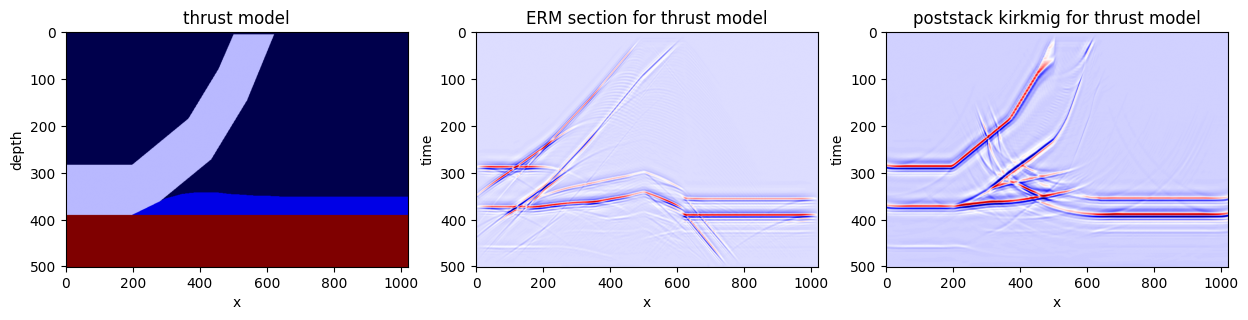

In [40]:
plt.figure(figsize=[15,5])
plt.subplot(1,3,1)
plt.imshow(vel, cmap='seismic', aspect=1.4)
plt.xlabel('x')
plt.ylabel('depth')
plt.title('thrust model')
plt.subplot(1,3,2)
plt.imshow(seisf, cmap='seismic', aspect=1.4)
plt.xlabel('x')
plt.ylabel('time')
plt.title('ERM section for thrust model')
plt.subplot(1,3,3)
plt.imshow(mig, cmap='seismic', aspect=1.4)
plt.xlabel('x')
plt.ylabel('time')
plt.title('poststack kirkmig for thrust model')
plt.show()